<a href="https://colab.research.google.com/github/Sanathcharan/Data-Science-ExcelR/blob/main/Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('tour_packages_lightgbm (1).csv')
df

,destination,duration_days,num_people,hotel_star_rating,transport_type,season,guide_included,activities_count,price
0,Dubai,14,1,5,Flight,Off-season,Yes,5,39510
1,London,9,2,4,Train,Off-season,Yes,5,31093
2,Bali,11,2,3,Bus,Peak,No,2,31199
3,London,10,4,5,Train,Off-season,No,4,35445
4,London,14,2,3,Bus,Off-season,Yes,2,31964
...,...,...,...,...,...,...,...,...,...
95,Bali,7,3,3,Train,Off-season,No,1,21919
96,London,3,1,3,Flight,Peak,Yes,3,19648
97,Goa,10,1,5,Bus,Off-season,Yes,1,27534
98,Goa,3,3,4,Flight,Peak,No,5,27352


In [ ]:
df.shape

(100, 9)

In [ ]:
df.size

900

In [ ]:
df.isnull().sum()

,0
destination,0
duration_days,0
num_people,0
hotel_star_rating,0
transport_type,0
season,0
guide_included,0
activities_count,0
price,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   destination        100 non-null    object
 1   duration_days      100 non-null    int64 
 2   num_people         100 non-null    int64 
 3   hotel_star_rating  100 non-null    int64 
 4   transport_type     100 non-null    object
 5   season             100 non-null    object
 6   guide_included     100 non-null    object
 7   activities_count   100 non-null    int64 
 8   price              100 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 7.2+ KB


<Axes: >

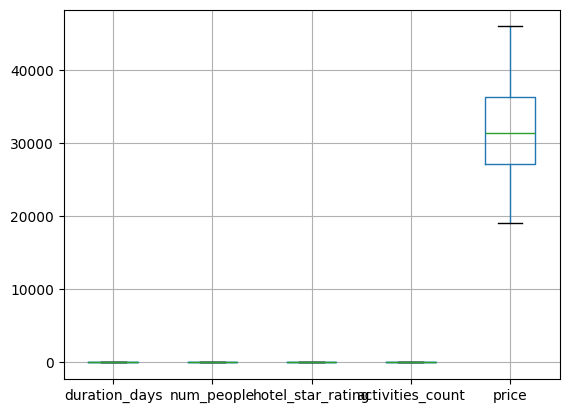

In [ ]:
df.boxplot()


In [ ]:
df.transport_type.value_counts()

,count
transport_type,
Train,37
Flight,34
Bus,29


In [ ]:
df.season.value_counts()

,count
season,
Peak,41
Off-season,33
Festival,26


In [ ]:
df.guide_included.value_counts()

,count
guide_included,
Yes,57
No,43


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder(categories=[['Bus','Train','Flight']])
df[['transport_type']]=oe.fit_transform(df[['transport_type']])

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder(categories=[['Off-season','Festival','Peak']])
df[['season']]=oe.fit_transform(df[['season']])
df

,destination,duration_days,num_people,hotel_star_rating,transport_type,season,guide_included,activities_count,price
0,Dubai,14,1,5,2.0,0.0,Yes,5,39510
1,London,9,2,4,1.0,0.0,Yes,5,31093
2,Bali,11,2,3,0.0,2.0,No,2,31199
3,London,10,4,5,1.0,0.0,No,4,35445
4,London,14,2,3,0.0,0.0,Yes,2,31964
...,...,...,...,...,...,...,...,...,...
95,Bali,7,3,3,1.0,0.0,No,1,21919
96,London,3,1,3,2.0,2.0,Yes,3,19648
97,Goa,10,1,5,0.0,0.0,Yes,1,27534
98,Goa,3,3,4,2.0,2.0,No,5,27352


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['destination']=le.fit_transform(df['destination'])
df

,destination,duration_days,num_people,hotel_star_rating,transport_type,season,guide_included,activities_count,price
0,1,14,1,5,2.0,0.0,Yes,5,39510
1,3,9,2,4,1.0,0.0,Yes,5,31093
2,0,11,2,3,0.0,2.0,No,2,31199
3,3,10,4,5,1.0,0.0,No,4,35445
4,3,14,2,3,0.0,0.0,Yes,2,31964
...,...,...,...,...,...,...,...,...,...
95,0,7,3,3,1.0,0.0,No,1,21919
96,3,3,1,3,2.0,2.0,Yes,3,19648
97,2,10,1,5,0.0,0.0,Yes,1,27534
98,2,3,3,4,2.0,2.0,No,5,27352


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df[['guide_included']]=oe.fit_transform(df[['guide_included']])
df

,destination,duration_days,num_people,hotel_star_rating,transport_type,season,guide_included,activities_count,price
0,1,14,1,5,2.0,0.0,1.0,5,39510
1,3,9,2,4,1.0,0.0,1.0,5,31093
2,0,11,2,3,0.0,2.0,0.0,2,31199
3,3,10,4,5,1.0,0.0,0.0,4,35445
4,3,14,2,3,0.0,0.0,1.0,2,31964
...,...,...,...,...,...,...,...,...,...
95,0,7,3,3,1.0,0.0,0.0,1,21919
96,3,3,1,3,2.0,2.0,1.0,3,19648
97,2,10,1,5,0.0,0.0,1.0,1,27534
98,2,3,3,4,2.0,2.0,0.0,5,27352


In [ ]:
x=df.drop(columns='price')
y=df['price']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=50)

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
gbr=AdaBoostRegressor()
gbr.fit(x_train,y_train)
pred_train=gbr.predict(x_train)
pred_test=gbr.predict(x_test)
from sklearn.metrics import r2_score
print("train accuracy",r2_score(y_train,pred_train))
print("test accuracy",r2_score(y_test,pred_test))

train accuracy 0.9140502112112872
test accuracy 0.7726367296132929


In [ ]:
from sklearn.model_selection import GridSearchCV
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1,10]
}
# Create a AdaBoost
abr_model = AdaBoostRegressor()
# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=abr_model, param_grid=param_grid, cv=5,scoring='r2')
# Fit the GridSearchCV object to the data
grid_search.fit(x_train, y_train)
# Print the best hyperparameters and the best score
print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
# Evaluate the best model on the test set
best_abr_model = grid_search.best_estimator_
y_pred_test_best = best_abr_model.predict(x_test)
test_accuracy_best = r2_score(y_test, y_pred_test_best)
print("Test accuracy of best model:", test_accuracy_best)

Best hyperparameters: {'learning_rate': 1, 'n_estimators': 200}
Best score: 0.7205590507654712
Test accuracy of best model: 0.7715707482793784


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
gbr=AdaBoostRegressor(estimator=LinearRegression())
gbr.fit(x_train,y_train)
pred_train=gbr.predict(x_train)
pred_test=gbr.predict(x_test)
from sklearn.metrics import r2_score
print("train accuracy",r2_score(y_train,pred_train))
print("test accuracy",r2_score(y_test,pred_test))

train accuracy 0.8866560900366884
test accuracy 0.865872982396444


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor()
gbr.fit(x_train,y_train)
pred_train=gbr.predict(x_train)
pred_test=gbr.predict(x_test)
from sklearn.metrics import r2_score
print("train accuracy",r2_score(y_train,pred_train))
print("test accuracy",r2_score(y_test,pred_test))

train accuracy 0.9916361335315556
test accuracy 0.8363504060708475


In [ ]:
from sklearn.model_selection import GridSearchCV
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1,10]
}
# Create a AdaBoost
gbr_model = GradientBoostingRegressor()
# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=gbr_model, param_grid=param_grid, cv=5,scoring='r2')
# Fit the GridSearchCV object to the data
grid_search.fit(x_train, y_train)
# Print the best hyperparameters and the best score
print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
# Evaluate the best model on the test set
best_gbr_model = grid_search.best_estimator_
y_pred_test_best = best_gbr_model.predict(x_test)
test_accuracy_best = r2_score(y_test, y_pred_test_best)
print("Test accuracy of best model:", test_accuracy_best)

Best hyperparameters: {'learning_rate': 0.1, 'n_estimators': 50}
Best score: 0.7440910855998752
Test accuracy of best model: 0.8264515823709733


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor
xgb=XGBRegressor()
xgb.fit(x_train,y_train)
pred_train=xgb.predict(x_train)
pred_test=xgb.predict(x_test)
from sklearn.metrics import r2_score
print("train accuracy",r2_score(y_train,pred_train))
print("test accuracy",r2_score(y_test,pred_test))

train accuracy 1.0
test accuracy 0.7428333759307861


In [ ]:
from sklearn.model_selection import GridSearchCV
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1,10]
}
# Create a AdaBoost
xgb_model = XGBRegressor()
# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5,scoring='r2')
# Fit the GridSearchCV object to the data
grid_search.fit(x_train, y_train)
# Print the best hyperparameters and the best score
print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
# Evaluate the best model on the test set
best_xgb_model = grid_search.best_estimator_
y_pred_test_best = best_xgb_model.predict(x_test)
test_accuracy_best = r2_score(y_test, y_pred_test_best)
print("Test accuracy of best model:", test_accuracy_best)

Best hyperparameters: {'learning_rate': 0.1, 'n_estimators': 200}
Best score: 0.6148363590240479
Test accuracy of best model: 0.7290442585945129


In [ ]:
!pip install lightgbm

In [ ]:
from lightgbm import LGBMRegressor
lgbm=LGBMRegressor()
lgbm.fit(x_train,y_train)
pred_train=lgbm.predict(x_train)
pred_test=lgbm.predict(x_test)
from sklearn.metrics import r2_score
print("train accuracy",r2_score(y_train,pred_train))
print("test accuracy",r2_score(y_test,pred_test))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 8
[LightGBM] [Info] Start training from score 31485.012500
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [ ]:
from sklearn.model_selection import GridSearchCV
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1,10]
}
# Create a AdaBoost
lgbm_model = LGBMRegressor()
# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=lgbm_model, param_grid=param_grid, cv=5,scoring='r2')
# Fit the GridSearchCV object to the data
grid_search.fit(x_train, y_train)
# Print the best hyperparameters and the best score
print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
# Evaluate the best model on the test set
best_lgbm_model = grid_search.best_estimator_
y_pred_test_best = best_lgbm_model.predict(x_test)
test_accuracy_best = r2_score(y_test, y_pred_test_best)
print("Test accuracy of best model:", test_accuracy_best)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000030 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40
[LightGBM] [Info] Number of data points in the train set: 64, number of used features: 8
[LightGBM] [Info] Start training from score 31444.578125
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM